# Titanic Survival Data Analysis

Author: Harry Bien-Aime

This project analyzes the Titanic passenger dataset to understand the factors that influenced survival during the Titanic disaster.

## Objective

The goal of this analysis is to explore the Titanic dataset and identify patterns that influenced passenger survival.

The analysis focuses on:

- gender differences in survival
- the impact of passenger class
- combined effects of gender and social class

## Dataset Description

The Titanic dataset contains information about passengers aboard the Titanic.

Key variables include:

- Survived: whether the passenger survived (1) or not (0)
- Pclass: passenger class (1 = first class, 3 = third class)
- Sex: gender of the passenger
- Age: passenger age
- Fare: ticket price
- Embarked: port where the passenger boarded the ship

Each row represents one passenger.

In [22]:
sns.set_style("whitegrid")

## Data Loading

In this section, we load the Titanic dataset using Python and pandas.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Data Cleaning

Real-world datasets often contain missing values.

In this step we:

- filled missing values in the Age column using the median
- filled missing Embarked values using the most frequent value
- removed the Cabin column because most values were missing

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop("Cabin", axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [11]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Exploratory Data Analysis

We explore survival patterns across different passenger groups using statistical summaries and visualizations.

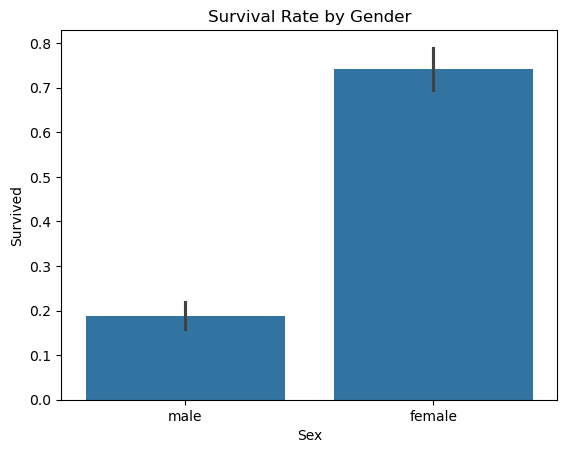

In [12]:
sns.barplot(data=df, x="Sex", y="Survived")

plt.title("Survival Rate by Gender")

plt.show()

### Insight

The visualization shows that female passengers had a significantly higher survival rate than male passengers.

This reflects the historical evacuation policy of "women and children first".

In [13]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

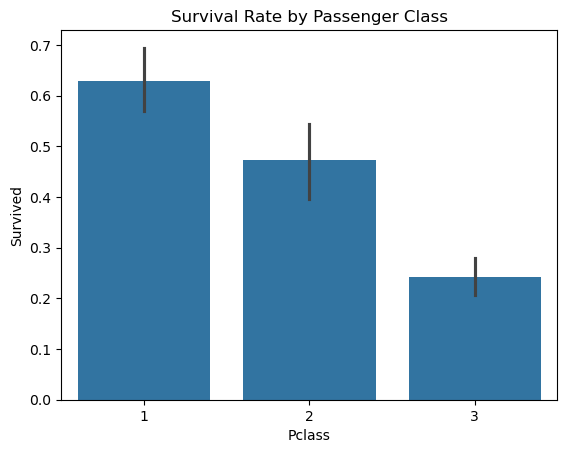

In [14]:
sns.barplot(data=df, x="Pclass", y="Survived")

plt.title("Survival Rate by Passenger Class")

plt.show()

### Insight
The analysis shows that passenger class hadevacuation a strong impact on survival. Approximately 63% of first-class passengers survived, compared to only about 24% of third-class passengers.This suggests that socioeconomic status may have influenced access to lifeboats and evacuations opportunities during the disaster.

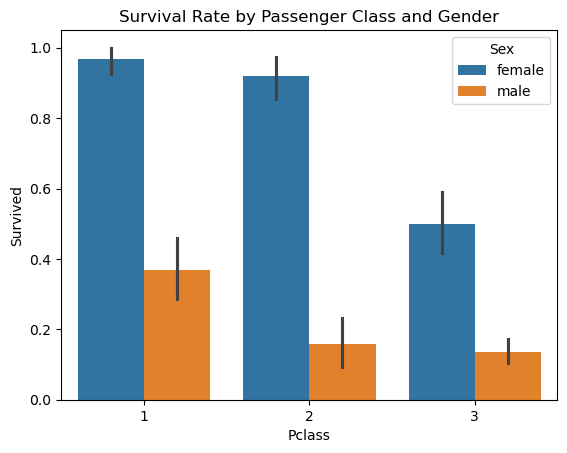

In [15]:
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")

plt.title("Survival Rate by Passenger Class and Gender")

plt.show()

### Insight

The combined analysis of gender and passenger class shows that survival was strongly influenced by both factors.

First-class female passengers had the highest survival rate, while third-class male passengers had the lowest survival rate.

This pattern reflects both the evacuation policy of "women and children first" and the advantages associated with higher socioeconomic status.

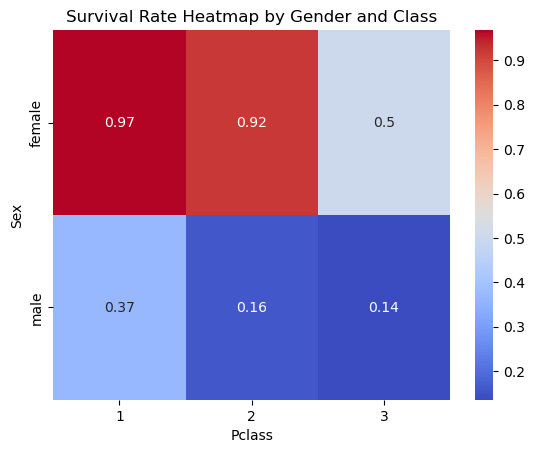

In [16]:
pivot_table = df.pivot_table(values="Survived", index="Sex", columns="Pclass")

sns.heatmap(pivot_table, annot=True, cmap="coolwarm")

plt.title("Survival Rate Heatmap by Gender and Class")

plt.show()

### Insight

The heatmap clearly shows that survival depended strongly on both gender and passenger class.

First-class female passengers had the highest survival probability, while third-class male passengers had the lowest survival rate.

This suggests that both evacuation policies and socioeconomic factors played important roles in determining survival outcomes.

In [17]:
### Survival Probability by Age

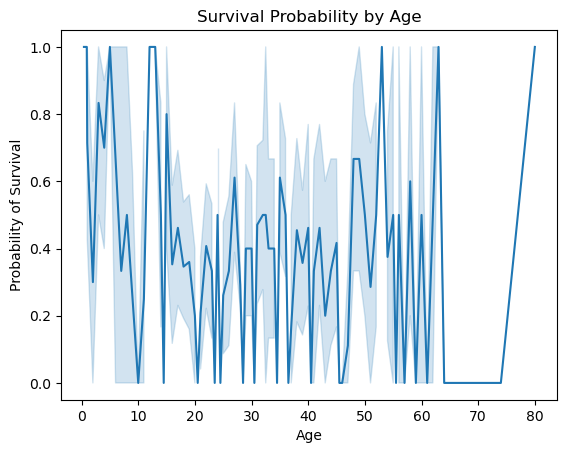

In [18]:
sns.lineplot(data=df, x="Age", y="Survived")

plt.title("Survival Probability by Age")

plt.xlabel("Age")

plt.ylabel("Probability of Survival")

plt.show()

### Insight

The survival probability curve shows how survival changes with passenger age.

Younger passengers tend to have higher survival probabilities, reflecting the evacuation policy of prioritizing women and children.

Survival probability generally decreases for older passengers.

### Age Distribution of Survivors vs Non-Survivors

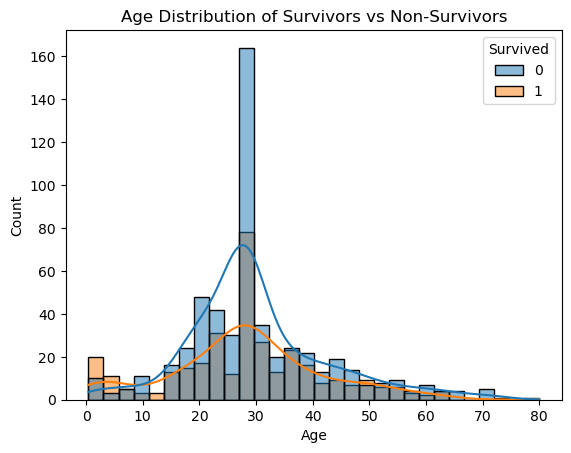

In [20]:
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)

plt.title("Age Distribution of Survivors vs Non-Survivors")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

### Insight

The age distribution shows differences between survivors and non-survivors.

Younger passengers appear more frequently among survivors, which supports the idea that children were prioritized during evacuation.

Older passengers show lower survival rates, suggesting that age played a role in survival outcomes.

### Correlation Between Numerical Variables

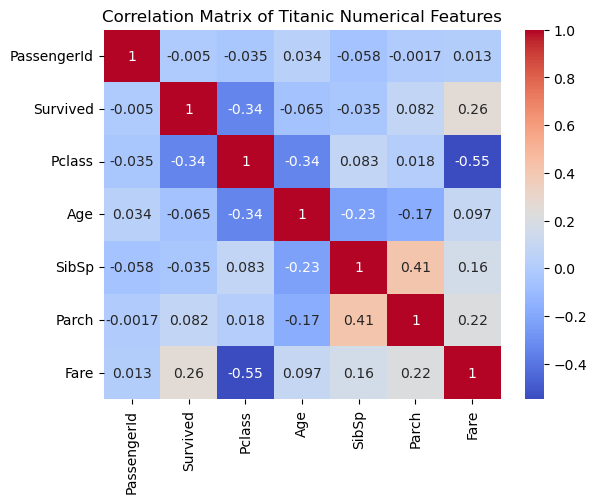

In [21]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlations
correlation_matrix = numeric_df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Titanic Numerical Features")

plt.show()

### Insight

The correlation matrix shows how numerical variables relate to each other.

Passenger class is negatively correlated with survival, meaning that passengers in higher classes (lower Pclass number) were more likely to survive.

Ticket fare is also correlated with passenger class, indicating that wealthier passengers tended to travel in higher classes.

Overall, socioeconomic status appears to have influenced survival outcomes.

## Conclusion

This analysis shows that survival during the Titanic disaster was strongly influenced by both gender and passenger class.

Women were more likely to survive than men, and passengers in higher social classes had better survival outcomes.

These findings highlight how both social policies and socioeconomic status influenced survival during the evacuation.